# EDA — bornes-dappel-taxi.csv
Urban Data Explorer · data.gouv.fr

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

## 1. Chargement

In [2]:
FILE = 'brute/indicateur-Score-accessibilité-mobilité/bornes-dappel-taxi.csv'

df = pd.read_csv(FILE, sep=None, engine='python')

# Nettoyage BOM UTF-8 (fréquent sur data.gouv)
df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=False)

print(f'Shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
df.head()

Shape : (420, 11)
Colonnes : ['id', 'nom', 'insee', 'adresse', 'emplacements', 'no_appel', 'info', 'statut', 'geo_shape', 'geopoint', 'geopoint_datagouv']


,id,nom,insee,adresse,emplacements,no_appel,info,statut,geo_shape,geopoint,geopoint_datagouv
0,75110-T-337,Alsace,75110.0,21 RUE D'ALSACE,5.0,NaN,NaN,en service,"{""coordinates"": [2.357864242070205, 48.8773924...","48.87739249960617, 2.357864242070205","2.357864242070205, 48.87739249960617"
1,75116-T-434,Boulainvilliers,75116.0,13 RUE DE BOULAINVILLIERS,2.0,NaN,NaN,en service,"{""coordinates"": [2.276475834811157, 48.8524728...","48.85247281585303, 2.276475834811157","2.276475834811157, 48.85247281585303"
2,75115-T-401,Sèvres / Hopital Necker,75115.0,106 RUE DE SEVRES,6.0,NaN,NaN,en service,"{""coordinates"": [2.313335777949898, 48.8457481...","48.84574816574562, 2.313335777949898","2.313335777949898, 48.84574816574562"
3,75115-T-393,Suffren,75115.0,94 AVENUE DE SUFFREN,6.0,NaN,NaN,en service,"{""coordinates"": [2.301671853290245, 48.8505193...","48.8505193588041, 2.301671853290245","2.301671853290245, 48.8505193588041"
4,75101-T-914,OPERA,75101.0,30 AVENUE DE L'OPERA,14.0,NaN,NaN,en service,"{""coordinates"": [2.3336487113910276, 48.868020...","48.86802072101611, 2.3336487113910276","2.3336487113910276, 48.86802072101611"


## 2. Infos générales

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 418 non-null    object 
 1   nom                420 non-null    object 
 2   insee              419 non-null    float64
 3   adresse            420 non-null    object 
 4   emplacements       418 non-null    float64
 5   no_appel           60 non-null     object 
 6   info               19 non-null     object 
 7   statut             420 non-null    object 
 8   geo_shape          420 non-null    object 
 9   geopoint           420 non-null    object 
 10  geopoint_datagouv  420 non-null    object 
dtypes: float64(2), object(9)
memory usage: 36.2+ KB


In [4]:
df.describe(include='all')

,id,nom,insee,adresse,emplacements,no_appel,info,statut,geo_shape,geopoint,geopoint_datagouv
count,418,420,419.000000,420,418.000000,60,19,420,420,420,420
unique,418,413,NaN,418,NaN,60,18,2,418,418,418
top,75103-T-007,Gare de Lyon SNCF,NaN,252 RUE DE RIVOLI,NaN,0143700000,115 au 117,en service,"{""coordinates"": [2.3426789722142547, 48.851663...","48.85166321384191, 2.3426789722142547","2.3426789722142547, 48.85166321384191"
freq,1,3,NaN,2,NaN,1,2,418,2,2,2
mean,NaN,NaN,75111.568019,NaN,7.217703,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,5.213805,NaN,6.652958,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,75101.000000,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,75108.000000,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,75112.000000,NaN,6.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,75116.000000,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Valeurs manquantes — critique pour ce dataset

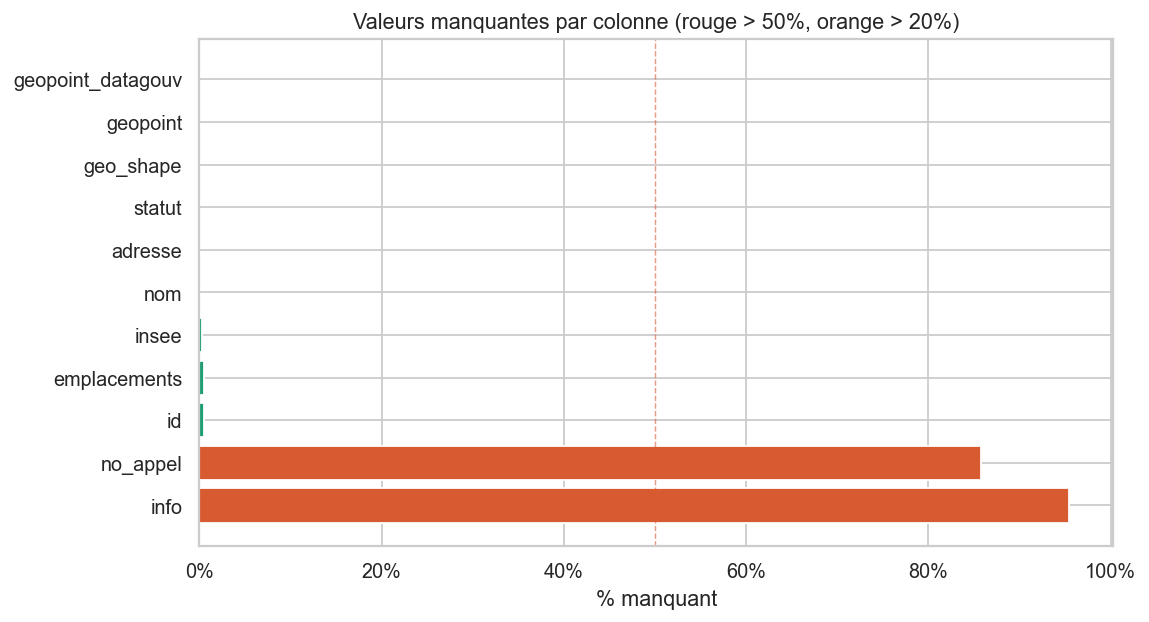

,% manquant
info,95.476190
no_appel,85.714286
id,0.476190
emplacements,0.476190
insee,0.238095
nom,0.000000
adresse,0.000000
statut,0.000000
geo_shape,0.000000
geopoint,0.000000


In [5]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, max(3, len(df.columns) * 0.45)))
colors = ['#D85A30' if v > 50 else '#BA7517' if v > 20 else '#1D9E75' for v in missing.values]
ax.barh(missing.index, missing.values, color=colors)
ax.set_xlabel('% manquant')
ax.set_title('Valeurs manquantes par colonne (rouge > 50%, orange > 20%)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.axvline(50, color='#D85A30', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

display(missing.rename('% manquant').to_frame())

## 4. Doublons

In [6]:
n_dup = df.duplicated().sum()
print(f'Doublons : {n_dup} ({n_dup/len(df)*100:.2f}%)')
if n_dup > 0:
    display(df[df.duplicated(keep=False)].head(10))

Doublons : 0 (0.00%)


## 5. Détection colonnes clés

In [7]:
def find_col(df, *keywords):
    for kw in keywords:
        match = [c for c in df.columns if kw.lower() in c.lower()]
        if match: return match[0]
    return None

col_map = {
    'id'           : find_col(df, 'id', 'identifiant'),
    'lat'          : find_col(df, 'lat', 'latitude', 'y_wgs'),
    'lon'          : find_col(df, 'lon', 'lng', 'longitude', 'x_wgs'),
    'commune'      : find_col(df, 'commune', 'ville', 'city', 'municipality'),
    'arrondissement': find_col(df, 'arrondissement', 'arrond', 'arr'),
    'adresse'      : find_col(df, 'adresse', 'address', 'rue', 'voie'),
    'etat'         : find_col(df, 'etat', 'état', 'statut', 'status', 'actif'),
    'date_maj'     : find_col(df, 'date', 'maj', 'update', 'modif'),
}

print('Colonnes détectées :')
for k, v in col_map.items():
    status = '✅' if v else '❌'
    print(f'  {status}  {k:20s} → {v}')

print(f'\nColonnes non mappées : {[c for c in df.columns if c not in col_map.values()]}')

Colonnes détectées :
  ✅  id                   → id
  ❌  lat                  → None
  ❌  lon                  → None
  ❌  commune              → None
  ❌  arrondissement       → None
  ✅  adresse              → adresse
  ✅  etat                 → statut
  ❌  date_maj             → None

Colonnes non mappées : ['nom', 'insee', 'emplacements', 'no_appel', 'info', 'geo_shape', 'geopoint', 'geopoint_datagouv']


## 6. Analyse géographique — répartition Paris vs reste

In [8]:
lat_col = col_map['lat']
lon_col = col_map['lon']

if lat_col and lon_col:
    df[lat_col] = pd.to_numeric(df[lat_col], errors='coerce')
    df[lon_col] = pd.to_numeric(df[lon_col], errors='coerce')
    geo = df[[lat_col, lon_col]].dropna()

    paris     = geo[(geo[lat_col].between(48.815, 48.902)) & (geo[lon_col].between(2.225, 2.470))]
    idf       = geo[(geo[lat_col].between(48.0, 49.4))    & (geo[lon_col].between(1.4, 3.6))]
    hors_idf  = geo[~geo.index.isin(idf.index)]

    print(f'Total avec coordonnées  : {len(geo):,}')
    print(f'Coordonnées manquantes  : {len(df) - len(geo):,} ({(len(df)-len(geo))/len(df)*100:.1f}%)')
    print(f'Paris intra-muros       : {len(paris):,}')
    print(f'IDF hors Paris          : {len(idf) - len(paris):,}')
    print(f'Hors IDF                : {len(hors_idf):,}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Scatter IDF
    axes[0].scatter(idf[lon_col], idf[lat_col], s=8, alpha=0.5, color='#378ADD', label='IDF')
    axes[0].scatter(paris[lon_col], paris[lat_col], s=12, alpha=0.8, color='#D85A30', label='Paris')
    axes[0].set_title('Distribution géographique — IDF')
    axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')
    axes[0].legend()

    # Scatter Paris uniquement
    axes[1].scatter(paris[lon_col], paris[lat_col], s=14, alpha=0.7, color='#D85A30')
    axes[1].set_title('Bornes taxi — Paris intra-muros')
    axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')

    plt.suptitle('Distribution géographique des bornes taxi', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('❌ Colonnes lat/lon non trouvées — vérifier les noms de colonnes')

❌ Colonnes lat/lon non trouvées — vérifier les noms de colonnes


## 7. Répartition par commune / arrondissement

In [9]:
commune_col = col_map['commune']
arr_col     = col_map['arrondissement']

if commune_col:
    print(f'Complétude commune : {df[commune_col].notna().sum()}/{len(df)} ({df[commune_col].notna().mean()*100:.1f}%)')
    top_communes = df[commune_col].value_counts().head(20)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(top_communes.index.astype(str), top_communes.values, color='#378ADD')
    ax.set_title('Top 20 communes par nb de bornes taxi')
    ax.set_xlabel('Nombre de bornes')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('❌ Colonne commune non trouvée')

if arr_col:
    print(f'\nComplétude arrondissement : {df[arr_col].notna().sum()}/{len(df)} ({df[arr_col].notna().mean()*100:.1f}%)')
    display(df[arr_col].value_counts().head(20))
else:
    print('⚠️  Colonne arrondissement non trouvée — reverse geocoding nécessaire en zone Silver')

❌ Colonne commune non trouvée
⚠️  Colonne arrondissement non trouvée — reverse geocoding nécessaire en zone Silver


## 8. Qualité des coordonnées GPS

In [10]:
if lat_col and lon_col:
    # Détection coordonnées aberrantes
    lat_ok = df[lat_col].between(41, 51)  # France métropolitaine
    lon_ok = df[lon_col].between(-5, 10)
    coords_valides = lat_ok & lon_ok

    print(f'Coordonnées valides (France)   : {coords_valides.sum():,} ({coords_valides.mean()*100:.1f}%)')
    print(f'Coordonnées aberrantes          : {(~coords_valides).sum():,}')
    print(f'Lat manquante                   : {df[lat_col].isna().sum():,}')
    print(f'Lon manquante                   : {df[lon_col].isna().sum():,}')

    if (~coords_valides).sum() > 0:
        print('\nExemples de coordonnées aberrantes :')
        display(df[~coords_valides][[lat_col, lon_col]].head(10))

## 9. Cardinalité des colonnes catégorielles

In [11]:
cat_cols = df.select_dtypes(include='object').columns
cardinality = pd.DataFrame({
    'colonne'    : cat_cols,
    'unique'     : [df[c].nunique() for c in cat_cols],
    'exemple'    : [str(df[c].dropna().iloc[0])[:50] if not df[c].dropna().empty else 'N/A' for c in cat_cols],
    '% manquant' : [round(df[c].isnull().mean() * 100, 1) for c in cat_cols],
}).sort_values('unique', ascending=False)

display(cardinality)

,colonne,unique,exemple,% manquant
0,id,418,75110-T-337,0.5
2,adresse,418,21 RUE D'ALSACE,0.0
8,geopoint_datagouv,418,"2.357864242070205, 48.87739249960617",0.0
7,geopoint,418,"48.87739249960617, 2.357864242070205",0.0
6,geo_shape,418,"{""coordinates"": [2.357864242070205, 48.8773924...",0.0
1,nom,413,Alsace,0.0
3,no_appel,60,0143700000,85.7
4,info,18,emplacements du 6 au 9 compris,95.5
5,statut,2,en service,0.0


## 10. Résumé + plan Silver

In [12]:
print('=' * 55)
print('RÉSUMÉ EDA — bornes-dappel-taxi.csv')
print('=' * 55)
print(f'  Lignes              : {len(df):,}')
print(f'  Colonnes            : {len(df.columns)}')
print(f'  Doublons            : {df.duplicated().sum()}')
missing_count = (df.isnull().sum() > 0).sum()
print(f'  Cols avec NaN       : {missing_count}')
if lat_col and lon_col:
    print(f'  Lat range           : {df[lat_col].min():.4f} → {df[lat_col].max():.4f}')
    print(f'  Lon range           : {df[lon_col].min():.4f} → {df[lon_col].max():.4f}')
print('=' * 55)
print()
print('ACTIONS SILVER REQUISES :')
if not col_map['arrondissement']:
    print('  ⚠️  Reverse geocoding lat/lon → arrondissement (API adresse.data.gouv.fr)')
print('  → Filtrer sur Paris uniquement (bbox ou code_insee 75xxx)')
print('  → Supprimer coordonnées aberrantes hors France')
print('  → Imputer communes manquantes via reverse geocoding')
print('  → Export Parquet partitionné par arrondissement')

RÉSUMÉ EDA — bornes-dappel-taxi.csv
  Lignes              : 420
  Colonnes            : 11
  Doublons            : 0
  Cols avec NaN       : 5

ACTIONS SILVER REQUISES :
  ⚠️  Reverse geocoding lat/lon → arrondissement (API adresse.data.gouv.fr)
  → Filtrer sur Paris uniquement (bbox ou code_insee 75xxx)
  → Supprimer coordonnées aberrantes hors France
  → Imputer communes manquantes via reverse geocoding
  → Export Parquet partitionné par arrondissement


In [14]:
# Extraire arrondissement depuis insee (75101 → 1, 75120 → 20)
df[['lat', 'lon']] = df['geopoint'].str.split(',', expand=True).astype(float)

# Extraire arrondissement en gérant le NaN
df['arrondissement'] = df['insee'].dropna().astype(int) - 75100

print(df[['nom', 'adresse', 'lat', 'lon', 'arrondissement']].head())

print(df[['nom', 'adresse', 'lat', 'lon', 'arrondissement']].head())

                       nom                    adresse        lat       lon  \
0                   Alsace            21 RUE D'ALSACE  48.877392  2.357864   
1          Boulainvilliers  13 RUE DE BOULAINVILLIERS  48.852473  2.276476   
2  Sèvres / Hopital Necker          106 RUE DE SEVRES  48.845748  2.313336   
3                  Suffren       94 AVENUE DE SUFFREN  48.850519  2.301672   
4                    OPERA       30 AVENUE DE L'OPERA  48.868021  2.333649   

   arrondissement  
0            10.0  
1            16.0  
2            15.0  
3            15.0  
4             1.0  
                       nom                    adresse        lat       lon  \
0                   Alsace            21 RUE D'ALSACE  48.877392  2.357864   
1          Boulainvilliers  13 RUE DE BOULAINVILLIERS  48.852473  2.276476   
2  Sèvres / Hopital Necker          106 RUE DE SEVRES  48.845748  2.313336   
3                  Suffren       94 AVENUE DE SUFFREN  48.850519  2.301672   
4                    